# LAB-D3-02: Compact CNN and Feature Maps - Instructor Solution

> **Instructor only.** This notebook contains completed responses and teaching notes. Do not distribute it with participant materials.

**Purpose:** Build a compact image classifier while making channels, spatial shapes, parameter sharing, feature maps, curves, and mistakes observable.

**Objectives:** `OBJ-D3-01`, `OBJ-D3-03`  
**Estimated duration:** 60 minutes live; CPU target under 12 minutes  
**Prerequisites:** [LESSON-D3-01](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-01---depth-capacity-and-feature-reuse), [LESSON-D3-03](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-03---cnn-mechanics-locality-and-shared-detectors), [ACT-D3-03](../../day-3/challenges/day-3-challenges.md#act-d3-03---kernel-reveal-and-shape-trace), and `LAB-D3-01`  
**Environment:** CPU required; PyTorch and torchvision; packaged offline Fashion-MNIST fallback; network downloads are opt-in only

Workflow: **Inspect source -> Predict shapes -> Trigger bug -> Repair architecture -> Train -> Capture maps -> Diagnose images -> Explain**. The fallback is real but smaller: it validates the complete mechanics, not the full-split metric band.

## Instructor Briefing

**What and why:** This solution keeps images batch-first as `(B,C,H,W)`, uses local shared kernels, and makes every spatial/channel transition inspectable before training. The deliberate three-channel convolution must fail on one-channel Fashion-MNIST; the repair changes the model contract rather than duplicating channels without a reason.

**Expected fallback evidence:** mode `packaged_fashion_mnist_fallback`; splits `3000/800/800`; training-only mean/std about `0.2862/0.3531`; shape trace `(8,1,28,28) -> (8,16,28,28) -> (8,16,14,14) -> (8,32,14,14) -> (8,32,7,7) -> (8,1568)`; `105,866` trainable parameters; two-epoch validation near `0.762`; hooks removed after capturing `(1,16,28,28)` and `(1,32,14,14)`. The optional third epoch may be nearly flat. The fallback result does **not** validate the online/full-split `0.80-0.88` band or full-data throughput.

**Plot reading:** the input grid should preserve labels and one-channel structure; aligned curves should improve without implying convergence; early maps should retain finer spatial detail while later maps are coarser/more selective; confident-error panels must pair each image with its true and predicted labels. Feature maps are descriptive activations, not causal explanations or named concepts.

**Hint ladder:**
1. Read the input as `(batch, channel, height, width)` and compare the channel count with `Conv2d.in_channels`.
2. Apply convolution shape rules before pooling; same-padding keeps height/width here.
3. Halve spatial dimensions at each `2x2` pool, then multiply `channels x height x width` for the flattened width.
4. Register temporary hooks only on the two convolution modules, detach captured tensors, and remove every handle.

**Likely misconceptions:** pooling changes channel count; batch size contributes parameters; each image location learns a separate kernel; an activation map proves what a unit represents; evaluation may reuse training augmentation; a smaller fallback score can be judged against the full-data band.

**Discussion triggers:** What invariance does sharing encourage, and what assumption does it make? Why can later maps be spatially coarser yet useful? Which error pairs suggest representation overlap rather than an indexing defect?

**Troubleshooting and alternatives:** Restore one-channel inputs, fixed normalization, and supplied seeds if shapes or bands drift. `nn.Sequential` blocks or an equivalent explicit forward pass are acceptable if the trace and parameter ceiling remain intact. If a live run is slow, keep the two core epochs and skip the optional third; do not substitute saved predictions for training evidence. CPU is the release baseline. A GPU may shorten training, but device-specific timings and small numerical differences require fresh validation. Cache or opt-in download mode must be reported explicitly.

In [1]:
%matplotlib inline
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DATA_SEED = 3201
MODEL_SEED = 3202
BATCH_SEED = 3203
DEVICE = torch.device("cpu")
ALLOW_DOWNLOAD = False  # Change to True only when network use is intentional.
EPOCHS = 2
BATCH_SIZE = 128
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.2})

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_all_seeds(MODEL_SEED)
print(f"Python {platform.python_version()} | torch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Required device: {DEVICE}; optional accelerators do not change required evidence.")

Python 3.11.8 | torch 2.6.0 | torchvision 0.21.0
Required device: cpu; optional accelerators do not change required evidence.


## Data and Offline Contract

With an existing torchvision cache or `ALLOW_DOWNLOAD=True`, the notebook uses a seeded, stratified Fashion-MNIST split of about `10,000/2,000/2,000`. Otherwise it loads the repository's balanced `3,000/800/800` Fashion-MNIST subset. The fallback preserves image/label provenance, shape work, bounded training, map capture, and error inspection. It does **not** validate the full-split `0.80-0.88` validation band or full-data throughput.

Predict which mode will be selected before loading. If opting into download, expect roughly 30 MB and cache the result for later labs.

In [2]:
source_prediction = {
    "expected_mode": "packaged_fashion_mnist_fallback because downloads are disabled and no course cache is assumed",
    "expected_train_val_test_counts": "3000/800/800",
    "input_shape": "(B, 1, 28, 28)",
    "which_statistics_may_use_training_only": "Normalization mean and standard deviation",
}
assert all(value.strip() for value in source_prediction.values())

In [3]:
from pathlib import Path

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-3/manifest.json").exists():
            return candidate
    raise FileNotFoundError(
        "Day 3 support files are missing. Run from a repository checkout and see courseware/shared/environment.md."
    )

def balanced_indices(labels, count, seed):
    labels = np.asarray(labels)
    classes = np.unique(labels)
    rng = np.random.default_rng(seed)
    per_class = count // len(classes)
    selected = np.concatenate([
        rng.choice(np.flatnonzero(labels == class_id), size=per_class, replace=False)
        for class_id in classes
    ])
    return selected[rng.permutation(len(selected))]

def load_fashion_splits(allow_download=False):
    repo_root = find_repo_root()
    cache_root = repo_root / ".cache/day-3/torchvision"
    source_error = None
    try:
        from torchvision.datasets import FashionMNIST
        train_source = FashionMNIST(cache_root, train=True, download=allow_download)
        test_source = FashionMNIST(cache_root, train=False, download=allow_download)
        train_images_all = train_source.data.numpy()
        train_labels_all = train_source.targets.numpy()
        test_images_all = test_source.data.numpy()
        test_labels_all = test_source.targets.numpy()
        pool = balanced_indices(train_labels_all, 12000, DATA_SEED)
        train_indices, val_indices = train_test_split(
            pool, train_size=10000, test_size=2000, stratify=train_labels_all[pool], random_state=DATA_SEED
        )
        test_indices = balanced_indices(test_labels_all, 2000, DATA_SEED + 1)
        arrays = {
            "train_images": train_images_all[train_indices], "train_labels": train_labels_all[train_indices],
            "val_images": train_images_all[val_indices], "val_labels": train_labels_all[val_indices],
            "test_images": test_images_all[test_indices], "test_labels": test_labels_all[test_indices],
            "class_names": np.asarray(train_source.classes),
        }
        mode = "fashion_mnist_cache_or_opt_in_download"
    except Exception as error:
        source_error = str(error)
        fallback_path = repo_root / "courseware/shared/data/day-3/fashion_mnist_fallback.npz"
        loaded = np.load(fallback_path, allow_pickle=False)
        arrays = {name: loaded[name] for name in loaded.files if name not in {"seed"}}
        mode = "packaged_fashion_mnist_fallback"
    mean = float(arrays["train_images"].mean() / 255.0)
    std = float(arrays["train_images"].std() / 255.0)
    def as_tensor(images):
        values = torch.tensor(images, dtype=torch.float32).unsqueeze(1) / 255.0
        return (values - mean) / std
    tensors = {
        "X_train": as_tensor(arrays["train_images"]),
        "y_train": torch.tensor(arrays["train_labels"], dtype=torch.long),
        "X_val": as_tensor(arrays["val_images"]),
        "y_val": torch.tensor(arrays["val_labels"], dtype=torch.long),
        "X_test": as_tensor(arrays["test_images"]),
        "y_test": torch.tensor(arrays["test_labels"], dtype=torch.long),
        "class_names": list(arrays["class_names"]),
        "mode": mode,
        "source_error": source_error,
        "mean": mean,
        "std": std,
    }
    return tensors

In [4]:
data = load_fashion_splits(ALLOW_DOWNLOAD)
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]
print("Source mode:", data["mode"])
if data["source_error"]:
    print("Cache/download path unavailable; recovery reason:", data["source_error"])
print("Split shapes:", X_train.shape, X_val.shape, X_test.shape)
print(f"Training-only normalization mean/std: {data['mean']:.4f}/{data['std']:.4f}")
assert X_train.ndim == 4 and X_train.shape[1:] == (1, 28, 28)
assert X_val.shape[1:] == X_test.shape[1:] == (1, 28, 28)

Source mode: packaged_fashion_mnist_fallback
Cache/download path unavailable; recovery reason: Dataset not found. You can use download=True to download it
Split shapes: torch.Size([3000, 1, 28, 28]) torch.Size([800, 1, 28, 28]) torch.Size([800, 1, 28, 28])
Training-only normalization mean/std: 0.2862/0.3531


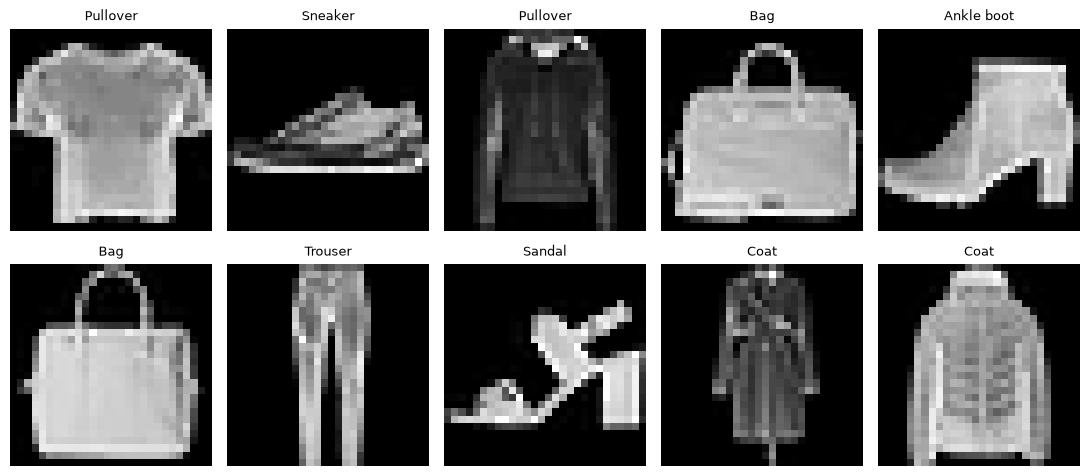

In [5]:
generator = torch.Generator().manual_seed(BATCH_SEED)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
first_images, first_labels = next(iter(train_loader))
assert first_images.shape == (BATCH_SIZE, 1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(first_images[index, 0] * data["std"] + data["mean"], cmap="gray")
    ax.set_title(class_names[int(first_labels[index])], fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## Predict the Shape Trace

The intended network has two blocks: `Conv(1,16,3,pad=1) -> ReLU -> MaxPool(2)` and `Conv(16,32,3,pad=1) -> ReLU -> MaxPool(2)`, followed by a small dense head. Predict every `(B,C,H,W)` shape, the flattened width, and whether the model stays below 250,000 trainable parameters.

In [6]:
architecture_predictions = {
    "after_block_1": "(B, 16, 14, 14)",
    "after_block_2": "(B, 32, 7, 7)",
    "flattened_width": "1568",
    "logits_shape": "(B, 10)",
    "parameter_count_band": "about 106k, below 250k",
    "early_vs_late_map_detail": "Early maps should retain fine spatial detail; later maps should be coarser and more selective.",
}
assert all(value.strip() for value in architecture_predictions.values())

## Deliberate Failure: Channel Order

PyTorch image batches are `(B,C,H,W)`. The broken layer below expects three channels. Predict the exception category, run the caught failure, then use the printed shape as evidence for the architecture TODO.

In [7]:
channel_bug_prediction = "RuntimeError: the layer expects 3 channels but the batch has 1."
assert channel_bug_prediction.strip()
channel_bug_observed = False
try:
    nn.Conv2d(3, 16, kernel_size=3, padding=1)(first_images[:4])
except RuntimeError as error:
    channel_bug_observed = True
    print("Expected channel diagnostic:", str(error).splitlines()[0])
assert channel_bug_observed

Expected channel diagnostic: Given groups=1, weight of size [16, 3, 3, 3], expected input[4, 1, 28, 28] to have 3 channels, but got 1 channels instead


## Modify: Implement the Compact CNN

Complete the modules and forward pass. Return raw logits for `CrossEntropyLoss`; do not apply softmax in the model. Preserve the two named convolution modules because the map-capture task hooks them later.

In [8]:
class CompactCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, images):
        values = self.pool(torch.relu(self.conv1(images)))
        values = self.pool(torch.relu(self.conv2(values)))
        return self.classifier(torch.flatten(values, 1))

set_all_seeds(MODEL_SEED)
model = CompactCNN().to(DEVICE)
sample_logits = model(first_images[:8])
parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
assert sample_logits.shape == (8, 10)
assert parameter_count < 250_000
print(f"Trainable parameters: {parameter_count:,}")

Trainable parameters: 105,866


## Shape Trace Checkpoint

Inspect intermediate shapes directly. Shape correctness is necessary, but it does not prove that the learned representation is useful.

In [9]:
def trace_shapes(model, images):
    trace = {"input": tuple(images.shape)}
    values = torch.relu(model.conv1(images)); trace["conv1"] = tuple(values.shape)
    values = model.pool(values); trace["pool1"] = tuple(values.shape)
    values = torch.relu(model.conv2(values)); trace["conv2"] = tuple(values.shape)
    values = model.pool(values); trace["pool2"] = tuple(values.shape)
    trace["flatten"] = tuple(torch.flatten(values, 1).shape)
    return trace

shape_trace = trace_shapes(model, first_images[:8])
print(shape_trace)
assert shape_trace == {
    "input": (8, 1, 28, 28), "conv1": (8, 16, 28, 28), "pool1": (8, 16, 14, 14),
    "conv2": (8, 32, 14, 14), "pool2": (8, 32, 7, 7), "flatten": (8, 1568),
}

{'input': (8, 1, 28, 28), 'conv1': (8, 16, 28, 28), 'pool1': (8, 16, 14, 14), 'conv2': (8, 32, 14, 14), 'pool2': (8, 32, 7, 7), 'flatten': (8, 1568)}


## Modify: Complete One Training Epoch

Use `model.train()`, move nothing off CPU, then repeat `zero_grad -> logits -> loss -> backward -> step`. Return example-weighted mean loss and accuracy. Evaluation is supplied and uses `model.eval()` plus `torch.inference_mode()`.

In [10]:
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = total_correct = total_examples = 0
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * len(targets)
        total_correct += int((logits.argmax(1) == targets).sum())
        total_examples += len(targets)
    return total_loss / total_examples, total_correct / total_examples

def evaluate(model, loader):
    model.eval()
    total_loss = total_correct = total_examples = 0
    all_probabilities, all_targets = [], []
    with torch.inference_mode():
        for images, targets in loader:
            logits = model(images.to(DEVICE))
            loss = loss_fn(logits, targets.to(DEVICE))
            probabilities = torch.softmax(logits, dim=1)
            total_loss += float(loss.item()) * len(targets)
            total_correct += int((logits.argmax(1).cpu() == targets).sum())
            total_examples += len(targets)
            all_probabilities.append(probabilities.cpu())
            all_targets.append(targets)
    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "probabilities": torch.cat(all_probabilities),
        "targets": torch.cat(all_targets),
    }

## Predict Before Training

Predict the loss direction, validation band for the selected source mode, and what train/validation divergence would suggest. The full `10k/2k/2k` path typically targets validation accuracy `0.80-0.88` after 2-3 bounded epochs. The smaller fallback has no promised copy of that band.

In [11]:
training_predictions = {
    "loss_direction": "Training loss should decrease over two epochs.",
    "validation_band_for_selected_mode": "No full-split 0.80-0.88 claim applies; fallback checkpoint requires at least 0.68.",
    "train_validation_relationship": "Both should improve, with a modest training advantage possible.",
    "what_would_falsify_healthy_training": "Non-finite or rising loss with validation near chance would reject it.",
}
assert all(value.strip() for value in training_predictions.values())

In [12]:
set_all_seeds(MODEL_SEED)
model = CompactCNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
training_started = time.perf_counter()
for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer)
    val_evidence = evaluate(model, val_loader)
    history["train_loss"].append(train_loss); history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_evidence["loss"]); history["val_accuracy"].append(val_evidence["accuracy"])
    print(f"epoch {epoch + 1}: train loss={train_loss:.4f}, train acc={train_accuracy:.3f}, val acc={val_evidence['accuracy']:.3f}")
training_seconds = time.perf_counter() - training_started
print(f"Bounded training time: {training_seconds:.2f}s")
assert np.isfinite(history["train_loss"]).all()
if data["mode"] == "fashion_mnist_cache_or_opt_in_download":
    assert 0.80 <= history["val_accuracy"][-1] <= 0.88
else:
    assert history["val_accuracy"][-1] >= 0.68

epoch 1: train loss=1.5464, train acc=0.531, val acc=0.685


epoch 2: train loss=0.7570, train acc=0.722, val acc=0.762
Bounded training time: 0.81s


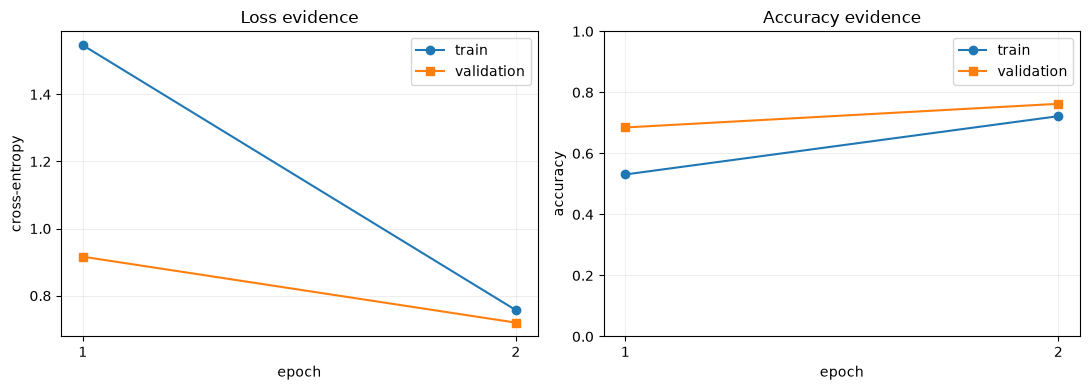

In [13]:
epochs_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_axis, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_axis, history["val_loss"], marker="s", label="validation")
axes[0].set(title="Loss evidence", xlabel="epoch", ylabel="cross-entropy", xticks=epochs_axis); axes[0].legend()
axes[1].plot(epochs_axis, history["train_accuracy"], marker="o", label="train")
axes[1].plot(epochs_axis, history["val_accuracy"], marker="s", label="validation")
axes[1].set(title="Accuracy evidence", xlabel="epoch", ylabel="accuracy", ylim=(0, 1), xticks=epochs_axis); axes[1].legend()
plt.tight_layout(); plt.show()

## Modify: Capture Feature Maps and Remove Hooks

Complete `capture_feature_maps`. Register hooks on `conv1` and `conv2`, run one evaluation forward pass, clone the outputs, and remove every handle in a `finally` block. Returning detached CPU tensors prevents the visualization from retaining the training graph.

In [14]:
def capture_feature_maps(model, image_batch):
    captured = {}
    handles = []
    def save(name):
        def hook(_module, _inputs, output):
            captured[name] = output.detach().cpu().clone()
        return hook
    handles.append(model.conv1.register_forward_hook(save("conv1")))
    handles.append(model.conv2.register_forward_hook(save("conv2")))
    try:
        model.eval()
        with torch.inference_mode():
            model(image_batch.to(DEVICE))
    finally:
        for handle in handles:
            handle.remove()
    hooks_removed = not model.conv1._forward_hooks and not model.conv2._forward_hooks
    return captured, hooks_removed

maps, hooks_removed = capture_feature_maps(model, X_val[:1])
assert maps["conv1"].shape == (1, 16, 28, 28)
assert maps["conv2"].shape == (1, 32, 14, 14)
assert hooks_removed and len(model.conv1._forward_hooks) == len(model.conv2._forward_hooks) == 0
print("Captured map shapes:", {name: tuple(values.shape) for name, values in maps.items()})

Captured map shapes: {'conv1': (1, 16, 28, 28), 'conv2': (1, 32, 14, 14)}


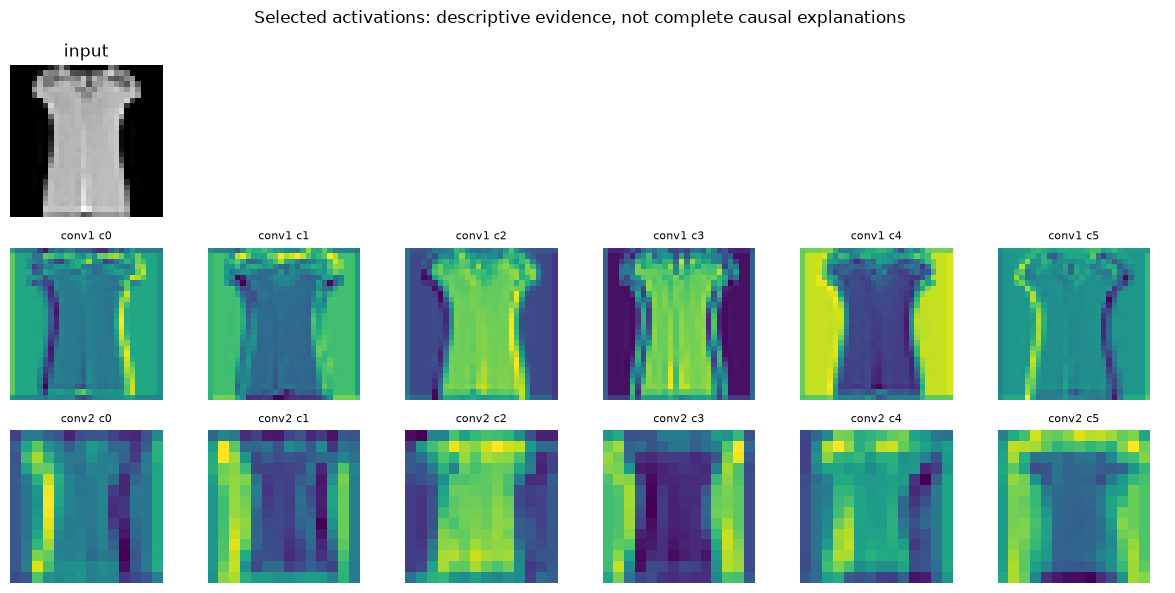

In [15]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
axes[0, 0].imshow(X_val[0, 0] * data["std"] + data["mean"], cmap="gray")
axes[0, 0].set_title("input"); axes[0, 0].axis("off")
for ax in axes[0, 1:]: ax.axis("off")
for row, (name, values) in enumerate(maps.items(), start=1):
    for channel, ax in enumerate(axes[row]):
        ax.imshow(values[0, channel], cmap="viridis")
        ax.set_title(f"{name} c{channel}", fontsize=8); ax.axis("off")
plt.suptitle("Selected activations: descriptive evidence, not complete causal explanations")
plt.tight_layout(); plt.show()

## Predict Before Revealing Misclassifications

Name two likely confusion pairs and one observation that would support ambiguity rather than an implementation bug. Then inspect the most confident validation mistakes.

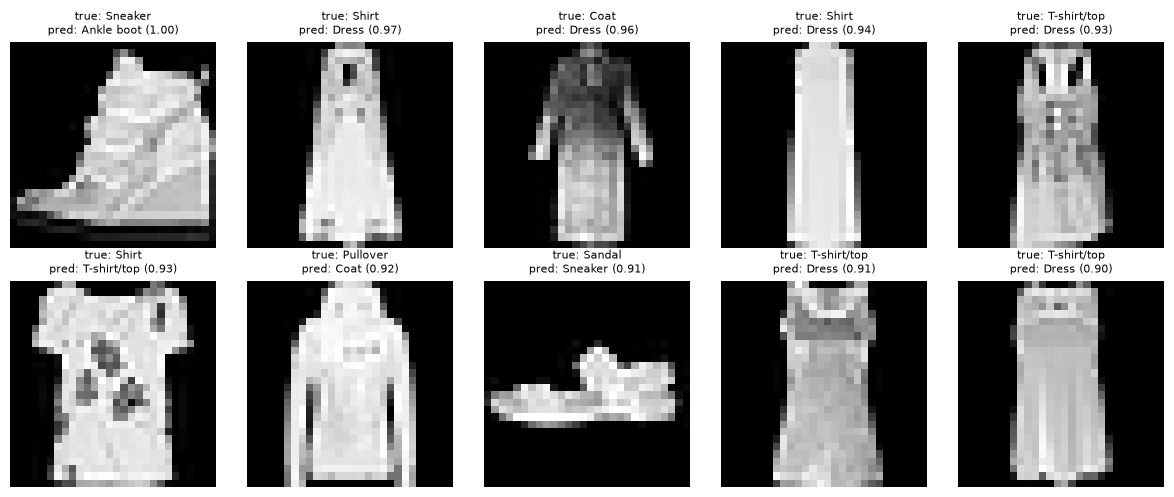

In [16]:
mistake_predictions = {
    "two_likely_confusions": "shirt versus T-shirt/top; coat versus pullover",
    "ambiguity_evidence": "Visually similar silhouettes with consistent true/predicted labels among otherwise correct examples.",
    "implementation_bug_evidence": "Systematic label-name mismatch or all predictions collapsing to one class.",
}
assert all(value.strip() for value in mistake_predictions.values())

validation = evaluate(model, val_loader)
predicted = validation["probabilities"].argmax(1)
confidence = validation["probabilities"].max(1).values
wrong = torch.nonzero(predicted != validation["targets"], as_tuple=False).flatten()
wrong = wrong[torch.argsort(confidence[wrong], descending=True)[:10]]
assert len(wrong) > 0
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for item_index, ax in zip(wrong.tolist(), axes.ravel()):
    ax.imshow(X_val[item_index, 0] * data["std"] + data["mean"], cmap="gray")
    true_name = class_names[int(y_val[item_index])]
    predicted_name = class_names[int(predicted[item_index])]
    ax.set_title(f"true: {true_name}\npred: {predicted_name} ({confidence[item_index]:.2f})", fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## Challenge: Map Evidence to Mechanism

Use the shape trace, parameter count, feature maps, and mistakes to explain locality and parameter sharing. State one map interpretation that remains only a hypothesis unless tested with controlled inputs.

In [17]:
cnn_interpretation = {
    "locality_evidence": "Each activation preserves a spatial grid and responds to local neighborhoods.",
    "parameter_sharing_benefit": "One kernel is reused at every position, reducing parameters and supporting translated patterns.",
    "early_vs_late_observation": "Early maps preserve outlines; later maps are lower-resolution and activate selectively.",
    "map_interpretation_limit": "Brightness alone cannot establish a named detector or causal role.",
    "mistake_category": "Several errors are between visually similar upper-body clothing categories.",
}
assert all(value.strip() for value in cnn_interpretation.values())

## Optional Extension: One Additional Epoch

Set `RUN_OPTIONAL_EPOCH = True`, predict both train and validation changes, then run one extra epoch. This is outside the core time budget and does not change the core checkpoint.

In [18]:
RUN_OPTIONAL_EPOCH = True
optional_epoch_prediction = "Training accuracy should rise; validation may improve more slowly or plateau."
if not RUN_OPTIONAL_EPOCH:
    print("Optional third epoch skipped. Core checkpoint is unaffected.")
else:
    assert optional_epoch_prediction.strip()
    extra_train_loss, extra_train_accuracy = train_epoch(model, train_loader, optimizer)
    extra_val = evaluate(model, val_loader)
    print(f"optional epoch: train acc={extra_train_accuracy:.3f}, val acc={extra_val['accuracy']:.3f}")
    optional_epoch_interpretation = "Training and validation both improved, so the extra epoch still added useful fit rather than clear divergence."
    assert optional_epoch_interpretation.strip()

optional epoch: train acc=0.772, val acc=0.764


## Reflect and Checkpoint

Distinguish architecture correctness, optimization evidence, generalization evidence, and descriptive internal evidence. Explain why a bright feature map is not automatically a named detector or a complete explanation.

In [19]:
reflection = {
    "architecture_evidence": "The full shape trace, logits shape, and parameter count satisfy the design contract.",
    "optimization_evidence": "Finite decreasing training loss and increasing training accuracy show useful updates.",
    "generalization_evidence": "Validation accuracy improves on held-out fallback examples but does not establish the full-split band.",
    "feature_map_limit": "Maps describe internal responses; they do not alone prove semantic or causal importance.",
    "next_discriminating_experiment": "Occlude a local image region and measure the corresponding map and prediction change.",
}
assert all(value.strip() for value in reflection.values())
assert channel_bug_observed
assert parameter_count < 250_000
assert hooks_removed and not model.conv1._forward_hooks and not model.conv2._forward_hooks
assert training_seconds < 12 * 60
print("LAB-D3-02 checkpoint passed: input/feature shapes, compact training, temporary hooks, curves, and misclassifications inspected.")

LAB-D3-02 checkpoint passed: input/feature shapes, compact training, temporary hooks, curves, and misclassifications inspected.


## Takeaways

- Image tensors use batch, channel, height, and width dimensions.
- Convolutions reuse local parameters across spatial positions.
- Pooling reduces spatial resolution while later layers combine broader context.
- Curves, feature maps, and misclassifications answer different questions.
- Internal activations are descriptive evidence, not complete causal explanations.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Support file missing | Notebook is outside the repository checkout | Run from the checkout and verify `courseware/shared/data/day-3/manifest.json` |
| Download fails | Network unavailable or blocked | Keep `ALLOW_DOWNLOAD=False`; the packaged fallback loads automatically |
| Channel error | Layer expects RGB but input is grayscale | Use `in_channels=1` and inspect `(B,1,28,28)` |
| Flatten error | Pooling shape was guessed | Print the trace and use `32*7*7` |
| Validation changes between repeats | Evaluation stayed in train mode | Call `model.eval()` and use `torch.inference_mode()` |
| Hooks accumulate | Handles were not removed | Remove them in `finally`, then rerun from a clean kernel |
| Full split misses `0.80-0.88` | Seed, epochs, architecture, or data mode changed | Restore supplied settings; do not apply the full band to fallback mode |

## Continue

Return to the [LAB-D3-02 debrief](../../day-3/student-guide/day-3-student-guide.md#lab-d3-02-debrief---maps-are-evidence-not-verdicts). Review [LESSON-D3-01](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-01---depth-capacity-and-feature-reuse), [LESSON-D3-03](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-03---cnn-mechanics-locality-and-shared-detectors), and [ACT-D3-03](../../day-3/challenges/day-3-challenges.md#act-d3-03---kernel-reveal-and-shape-trace) as needed.